<a href="https://colab.research.google.com/github/wckdly/uos-ml-coursework/blob/main/aml_task1_code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Introduction
This Colab worksheet provides a starting point for Task 1 (the natural language processing task).

# Data Loading

In [1]:
# Download the data stored in a csv file
# If you're running all your experiments on a machine at home rather than using colab, then make sure you save it rather than repeatedly downloading it.

# training data
!wget "https://sussex.box.com/shared/static/xjewvhv527xq083j8ehtsjcijs1i4kra.csv" -O sentiment_analysis_training_data.csv
# validation data
!wget "https://sussex.box.com/shared/static/qv30jx3xfwer1va1k19nhndq2xaso67x.csv" -O sentiment_analysis_validation_data.csv
# test data (without labels)
!wget "https://sussex.box.com/shared/static/zu44986583mlocifzyx6dsmqe20g1hlh.csv" -O sentiment_analysis_test_data.csv

--2026-05-26 10:57:53--  https://sussex.box.com/shared/static/xjewvhv527xq083j8ehtsjcijs1i4kra.csv
Resolving sussex.box.com (sussex.box.com)... 74.112.186.157, 2620:117:bff0:12d::
Connecting to sussex.box.com (sussex.box.com)|74.112.186.157|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: /public/static/xjewvhv527xq083j8ehtsjcijs1i4kra.csv [following]
--2026-05-26 10:57:53--  https://sussex.box.com/public/static/xjewvhv527xq083j8ehtsjcijs1i4kra.csv
Reusing existing connection to sussex.box.com:443.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://sussex.app.box.com/public/static/xjewvhv527xq083j8ehtsjcijs1i4kra.csv [following]
--2026-05-26 10:57:53--  https://sussex.app.box.com/public/static/xjewvhv527xq083j8ehtsjcijs1i4kra.csv
Resolving sussex.app.box.com (sussex.app.box.com)... 74.112.186.157, 2620:117:bff0:12d::
Connecting to sussex.app.box.com (sussex.app.box.com)|74.112.186.157|:443... connected.
HTTP request

# Load the data

In [2]:
import pandas as pd

# load the training data using np.load
# repeat this for validation and test data, but note the latter has no labels
data_train = pd.read_csv('sentiment_analysis_training_data.csv')

# extract the text
text_train = data_train['text'].values
# and the labels
labels_train = data_train['label'].values
print(data_train.shape, text_train.shape, labels_train.shape)

data_val = pd.read_csv('sentiment_analysis_validation_data.csv')
# extract the text
text_val = data_val['text'].values
# and the labels
labels_val = data_val['label'].values
print(data_val.shape, text_val.shape, labels_val.shape)

data_test = pd.read_csv('sentiment_analysis_test_data.csv')
# extract the text
text_test = data_test['text'].values
print(data_test.shape, text_test.shape)

(11503, 2) (11503,) (11503,)
(1397, 2) (1397,) (1397,)
(1434, 1) (1434,)


# Data Visualisation
Here's an example of how to display the text based on its label.

In [3]:
def print_text(text, label):
  if label == 0:
    print (text, '\nlabel == 0')
  else:
    print (text, '\nlabel == 1')

import numpy as np
idx = np.random.randint(0, text_train.shape[0])
print_text(text_train[idx], labels_train[idx])

the entire movie is so formulaic and forgettable that it's hardly over before it begins to fade from memory . 
label == 0


# Calculating Confusion Matrix and exporting results

In [4]:
from sklearn.metrics import confusion_matrix

def get_confusion_matrix(true_label, pred_label):
  """
  Calculate the confusion matrix for your predicted labels. See https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html
  :param pred_label: Array of predicted labels
  :param true_label: Array of corresponding ground truth (test) labels
  :return: Confusion matrix whose i-th row and j-th column entry indicates the number of samples with true label being i-th class and predicted label being j-th class.
  """
  return confusion_matrix(true_label, pred_label)


In [5]:
def save_as_csv(pred_labels, location = '.'):
    """
    Save the labels out as a .csv file
    :pred_labels: numpy array of shape (no_test_labels,) to be saved
    :param location: Directory to save results.csv in. Default to current working directory
    """
    assert pred_labels.shape[0]==1434, 'wrong number of labels, should be 1434 test labels'
    np.savetxt(location + '/results_task1.csv', pred_labels, delimiter=',')


# Logistic Regression Model


In [6]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# convert text into numerical features
vectorizer = TfidfVectorizer(stop_words='english', max_features=5000)

# learn vocabulary from training data
X_train = vectorizer.fit_transform(text_train)

# transform validation data using same vocabulary
X_val = vectorizer.transform(text_val)

# create model
model = LogisticRegression(max_iter=1000)

# train model
model.fit(X_train, labels_train)

# make predictions
pred_val = model.predict(X_val)

# evaluate
accuracy = accuracy_score(labels_val, pred_val)

print("Validation Accuracy:", accuracy)

print("\nClassification Report:\n")
print(classification_report(labels_val, pred_val))

Validation Accuracy: 0.6721546170365068

Classification Report:

              precision    recall  f1-score   support

           0       0.66      0.69      0.68       693
           1       0.68      0.66      0.67       704

    accuracy                           0.67      1397
   macro avg       0.67      0.67      0.67      1397
weighted avg       0.67      0.67      0.67      1397



## Confusion Matrix Plot

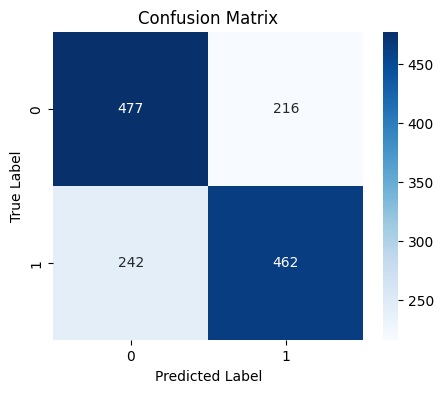

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = get_confusion_matrix(labels_val, pred_val)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")

plt.show()

## Printing reviews for manual checking

In [8]:
wrong_indices = np.where(pred_val != labels_val)[0]

print("Number of wrong predictions:", len(wrong_indices))

for i in wrong_indices[:10]:

    print("\nREVIEW:\n")
    print(text_val[i])

    print("\nTRUE LABEL:", labels_val[i])
    print("PREDICTED LABEL:", pred_val[i])

    print("\n" + "="*80)

Number of wrong predictions: 458

REVIEW:

it's a gag that's worn a bit thin over the years , though don't ask still finds a few chuckles .

TRUE LABEL: 0
PREDICTED LABEL: 1


REVIEW:

Subject: january nominations at shell deer park
fyi .
al
- - - - - - - - - - - - - - - - - - - - - - forwarded by aimee lannou / hou / ect on 01 / 16 / 2001 11 : 35
am - - - - - - - - - - - - - - - - - - - - - - - - - - -
mary poorman @ enron
01 / 16 / 2001 08 : 23 am
to : aimee lannou / hou / ect @ ect
cc :
subject : january nominations at shell deer park
- - - - - - - - - - - - - - - - - - - - - - forwarded by mary poorman / na / enron on 01 / 16 / 2001 08 : 23
am - - - - - - - - - - - - - - - - - - - - - - - - - - -
" shankster jl ( luther ) " on 12 / 19 / 2000 03 : 32 : 26 pm
to : " ' lamphier , gary ' "
cc : " carter , john " , " ricks , ruth " ,
kyle . r . lilly @ enron . com , mary . poorman @ enron . com
subject : january nominations at shell deer park
gary ,
january 2001 nominations for gas deli

# Naive Bayes Model

In [9]:
from sklearn.naive_bayes import MultinomialNB

# create model
nb_model = MultinomialNB()

# train model
nb_model.fit(X_train, labels_train)

# predict validation data
nb_pred = nb_model.predict(X_val)

# evaluate
nb_accuracy = accuracy_score(labels_val, nb_pred)

print("Naive Bayes Validation Accuracy:", nb_accuracy)

print("\nClassification Report:\n")
print(classification_report(labels_val, nb_pred))

Naive Bayes Validation Accuracy: 0.6635647816750179

Classification Report:

              precision    recall  f1-score   support

           0       0.65      0.68      0.67       693
           1       0.67      0.64      0.66       704

    accuracy                           0.66      1397
   macro avg       0.66      0.66      0.66      1397
weighted avg       0.66      0.66      0.66      1397



## Confusion Matrix Plot

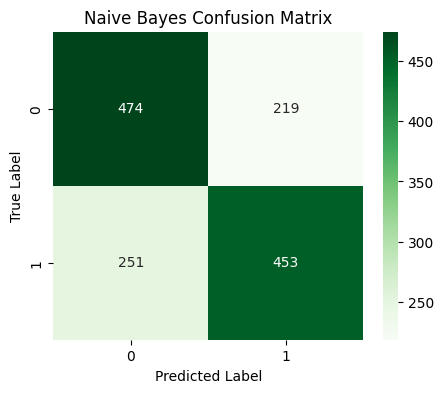

In [10]:
cm_nb = get_confusion_matrix(labels_val, nb_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Greens')

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Naive Bayes Confusion Matrix")

plt.show()

## Printing reviews for manual checking

In [11]:
wrong_indices_nb = np.where(nb_pred != labels_val)[0]

print("Number of wrong predictions:", len(wrong_indices_nb))

for i in wrong_indices_nb[:5]:

    print("\nREVIEW:\n")
    print(text_val[i])

    print("\nTRUE LABEL:", labels_val[i])
    print("PREDICTED LABEL:", nb_pred[i])

    print("\n" + "="*80)

Number of wrong predictions: 470

REVIEW:

it's a gag that's worn a bit thin over the years , though don't ask still finds a few chuckles .

TRUE LABEL: 0
PREDICTED LABEL: 1


REVIEW:

Subject: january nominations at shell deer park
fyi .
al
- - - - - - - - - - - - - - - - - - - - - - forwarded by aimee lannou / hou / ect on 01 / 16 / 2001 11 : 35
am - - - - - - - - - - - - - - - - - - - - - - - - - - -
mary poorman @ enron
01 / 16 / 2001 08 : 23 am
to : aimee lannou / hou / ect @ ect
cc :
subject : january nominations at shell deer park
- - - - - - - - - - - - - - - - - - - - - - forwarded by mary poorman / na / enron on 01 / 16 / 2001 08 : 23
am - - - - - - - - - - - - - - - - - - - - - - - - - - -
" shankster jl ( luther ) " on 12 / 19 / 2000 03 : 32 : 26 pm
to : " ' lamphier , gary ' "
cc : " carter , john " , " ricks , ruth " ,
kyle . r . lilly @ enron . com , mary . poorman @ enron . com
subject : january nominations at shell deer park
gary ,
january 2001 nominations for gas deli

# Improved Logistic Regression Model

In [12]:
# improved TF-IDF representation

better_vectorizer = TfidfVectorizer(
    stop_words='english',
    max_features=10000,
    ngram_range=(1,2),
    min_df=2
)

X_train_better = better_vectorizer.fit_transform(text_train)
X_val_better = better_vectorizer.transform(text_val)

better_model = LogisticRegression(max_iter=1000)

better_model.fit(X_train_better, labels_train)

better_pred = better_model.predict(X_val_better)

better_accuracy = accuracy_score(labels_val, better_pred)

print("Improved Logistic Regression Accuracy:", better_accuracy)

print("\nClassification Report:\n")
print(classification_report(labels_val, better_pred))

Improved Logistic Regression Accuracy: 0.677881173944166

Classification Report:

              precision    recall  f1-score   support

           0       0.67      0.70      0.68       693
           1       0.69      0.66      0.67       704

    accuracy                           0.68      1397
   macro avg       0.68      0.68      0.68      1397
weighted avg       0.68      0.68      0.68      1397



## Different regularisation strength evaluation and comparison

In [13]:
c_values = [0.1, 1, 3, 5]

for c in c_values:

    model_test = LogisticRegression(
        max_iter=1000,
        C=c
    )

    model_test.fit(X_train_better, labels_train)

    pred_test = model_test.predict(X_val_better)

    acc = accuracy_score(labels_val, pred_test)

    print(f"C={c}  --> Accuracy={acc}")

C=0.1  --> Accuracy=0.6628489620615605
C=1  --> Accuracy=0.677881173944166
C=3  --> Accuracy=0.677881173944166
C=5  --> Accuracy=0.6750178954903364


# Evaluation on NLTK movie_reviews

In [14]:
import nltk
from nltk.corpus import movie_reviews

nltk.download('movie_reviews')

# load reviews and labels
docs = []
labels = []

for fileid in movie_reviews.fileids():

    docs.append(movie_reviews.raw(fileid))

    if movie_reviews.categories(fileid)[0] == 'pos':
        labels.append(1)
    else:
        labels.append(0)

# transform using your improved TF-IDF vectorizer
X_external = better_vectorizer.transform(docs)

# predict using improved logistic regression model
external_pred = better_model.predict(X_external)

# evaluate
external_accuracy = accuracy_score(labels, external_pred)

print("External Dataset Accuracy:", external_accuracy)

print("\nClassification Report:\n")
print(classification_report(labels, external_pred))

[nltk_data] Downloading package movie_reviews to /root/nltk_data...
[nltk_data]   Unzipping corpora/movie_reviews.zip.


External Dataset Accuracy: 0.773

Classification Report:

              precision    recall  f1-score   support

           0       0.72      0.89      0.80      1000
           1       0.86      0.66      0.74      1000

    accuracy                           0.77      2000
   macro avg       0.79      0.77      0.77      2000
weighted avg       0.79      0.77      0.77      2000

